# LangGraph 활용 Agent 구축

이번 튜토리얼에서는 웹 검색 도구를 통해 챗봇에 웹 검색 기능수행하는 Agent 을 추가합니다.

LLM 에 도구를 바인딩하여 LLM 에 입력된 요청에 따라 필요시 웹 검색 도구(Tool)를 호출하는 Agent 을 구축합니다.

뿐만아니라, 조건부 엣지를 통해 도구 호출 여부에 따라 다른 노드로 라우팅하는 방법도 함께 배워봅니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv()

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("CH17-LangGraph-Modules")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH17-LangGraph-Modules


## 도구(Tool) 사용하기

**참고**

- [도구(Tools)](https://wikidocs.net/262582)

챗봇이 "기억"에서 답변할 수 없는 질문을 처리하기 위해 웹 검색 도구를 통합할 것입니다. 이 도구를 사용하여 관련 정보를 찾아 더 나은 응답을 제공할 수 있습니다.

### 검색 API 도구

Tavily 검색 API를 활용하여 검색 기능을 구현하는 도구입니다. 이 도구는 두 가지 주요 클래스를 제공합니다: `TavilySearchResults`와 `TavilyAnswer`.

**API 키 발급 주소**
- https://app.tavily.com/

발급한 API 키를 환경변수에 설정합니다.

`.env` 파일에 아래와 같이 설정합니다.

```
TAVILY_API_KEY=tvly-abcdefghijklmnopqrstuvwxyz
```

### TavilySearchResults

**설명**
- Tavily 검색 API를 쿼리하고 JSON 형식의 결과를 반환합니다.
- 포괄적이고 정확하며 신뢰할 수 있는 결과에 최적화된 검색 엔진입니다.
- 현재 이벤트에 대한 질문에 답변할 때 유용합니다.

다음으로 웹 검색 도구인 `TavilySearchResults`를 생성합니다.

In [7]:
# !pip install -U langchain-teddynote

In [3]:
from langchain_teddynote.tools.tavily import TavilySearch

# 검색 도구 생성
tool = TavilySearch(max_results=3)

# 도구 목록에 추가
tools = [tool]

# 도구 실행
print(tool.invoke("테디노트 랭체인 튜토리얼"))

[{'url': 'https://www.youtube.com/watch?v=mVu6Wj8Z7C0', 'title': '랭체인 한국어 튜토리얼     업데이트 소식   처음 사용자를 위한 친절한 ...', 'content': '#랭체인 한국어 튜토리얼🇰🇷 업데이트 소식🔥 처음 사용자를 위한 친절한 환경설치(Windows, Mac)\n테디노트 TeddyNote\n47000 subscribers\n333 likes\n18455 views\n19 Jun 2024\n📝 환경설정(Windows)\nhttps://teddynote.com/10-RAG%EB%B9%84%EB%B2%95%EB%85%B8%ED%8A%B8/%ED%99%98%EA%B2%BD%20%EC%84%A4%EC%A0%95%20(Windows)/\n\n📝 환경설정(Mac)\nhttps://teddynote.com/10-RAG%EB%B9%84%EB%B2%95%EB%85%B8%ED%8A%B8/%ED%99%98%EA%B2%BD%20%EC%84%A4%EC%A0%95%20(Mac)/\n\n📍[패스트캠퍼스] "테디노트의 RAG 비법노트" 강의\n링크: https://bit.ly/4e1h8zO\n\n🤖 디스코드 채널\nhttps://discord.gg/q3RvQZ5CfK\n\n📘 랭체인 튜토리얼 무료 전자책(wikidocs)\nhttps://wikidocs.net/book/14314\n\n✅ 랭체인 한국어 튜토리얼 코드저장소(GitHub)\nhttps://github.com/teddylee777/langchain-kr\n\n✅ 줄거리\n00:00 랭체인 한국어 튜토리얼 공지사항\n01:59 langchain-teddynote 패키지\n08:25 감사인사\n09:15 Windows 환경설치\n21:48 Mac 환경설치\n\n#rag #langchain\n---\n📍 "테디노트의 RAG 비법노트" 랭체인 강의: https://fastcampus.co.kr/data_online_teddy\n📘 랭체인 한국어 튜토리얼(무료 전자책)

결과는 챗봇이 질문에 답할 수 있도록 사용할 수 있는 페이지 요약입니다.

이번에는 LLM에 `bind_tools`를 추가하여 **LLM + 도구** 를 구성합니다. 

![alt text](image.png)

In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


# State 정의 (상태 메세지를 저장)
class State(TypedDict):
    # list 타입에 add_messages 적용(list 에 message 추가)
    messages: Annotated[list, add_messages]

LLM 을 정의하고 도구를 바인딩합니다.

In [5]:
from langchain_openai import ChatOpenAI

# LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini")

# TavilySearch 도구를 LLM에 바인딩
# TavilySearch의 검색 결과를 LLM 프롬프트에 포함
llm_with_tools = llm.bind_tools(tools)

노드를 정의합니다.

- 이 코드는 **LangGraph**에서 **'챗봇' 노드**를 정의하는 예시입니다. 
- 이 노드는 **OpenAI의 LLM**을 사용하고, `llm.bind_tools()`를 통해 외부 도구(예: `TavilySearch`)와 
  연결하여 LLM이 더 풍부하고 정확한 답변을 생성할 수 있도록 합니다.
- `add_messages`는 이 노드가 대화의 흐름을 효율적으로 관리할 수 있게 돕는 역할을 합니다.

In [6]:
# 노드 함수 정의
def chatbot(state: State):
    answer = llm_with_tools.invoke(state["messages"])
    # 메시지 목록 반환
    return {"messages": [answer]}  # 자동으로 add_messages 적용

그래프 생성 및 노드를 추가합니다.

In [7]:
from langgraph.graph import StateGraph

# 상태 그래프 초기화
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("chatbot", chatbot)

## 도구 노드(Tool Node)

다음으로, 도구가 호출될 경우 실제로 실행할 수 있는 함수를 만들어야 합니다. 이를 위해 새로운 노드에 도구를 추가합니다.

가장 최근의 메시지를 확인하고 메시지에 `tool_calls`가 포함되어 있으면 도구를 호출하는 `BasicToolNode`를 구현합니다. 


**지금은 직접 구현하지만, 나중에는 LangGraph의 pre-built 되어있는** [ToolNode](https://langchain-ai.github.io/langgraph/reference/prebuilt/#langgraph.prebuilt.tool_node.ToolNode) **로 대체할 수 있습니다.**

In [8]:
import json
from langchain_core.messages import ToolMessage


class BasicToolNode:
    """Run tools requested in the last AIMessage node"""

    def __init__(self, tools: list) -> None:
        # 도구 리스트
        self.tools_list = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        # 메시지가 존재할 경우 가장 최근 메시지 1개 추출
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")

        # 도구 호출 결과
        outputs = []
        for tool_call in message.tool_calls:
            # 도구 호출 후 결과 저장
            tool_result = self.tools_list[tool_call["name"]].invoke(tool_call["args"])
            outputs.append(
                # 도구 호출 결과를 메시지로 저장
                ToolMessage(
                    content=json.dumps(
                        tool_result, ensure_ascii=False
                    ),  # 도구 호출 결과를 문자열로 변환
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )

        return {"messages": outputs}


# 도구 노드 생성
tool_node = BasicToolNode(tools=[tool])

# 그래프에 도구 노드 추가
graph_builder.add_node("tools", tool_node)

## 조건부 엣지(Conditional Edge)

도구 노드가 추가되면 `conditional_edges`를 정의할 수 있습니다.

**Edges**는 한 노드에서 다음 노드로 제어 흐름을 라우팅합니다. 

**Conditional edges**는 일반적으로 "if" 문을 포함하여 현재 그래프 상태에 따라 다른 노드로 라우팅합니다. 이러한 함수는 현재 그래프 `state`를 받아 다음에 호출할 Node 를 나타내는 **문자열 또는 문자열 목록** 을 반환합니다.

아래에서는 `route_tools`라는 라우터 함수를 정의하여 챗봇의 출력에서 `tool_calls`를 확인합니다. 

이 함수를 `add_conditional_edges`를 호출하여 그래프에 제공하면, `chatbot` 노드가 완료될 때마다 이 함수를 확인하여 다음으로 어디로 갈지 결정합니다.

조건은 도구 호출이 있으면 `tools`로, 없으면 `END`로 라우팅됩니다.

**참고**

- langgraph 에 pre-built 되어 있는 [tools_condition](https://langchain-ai.github.io/langgraph/reference/prebuilt/#tools_condition) 으로 대체할 수 있습니다.

### `add_conditional_edges`

![add_conditional_edges](./image/langgraph-02.png)

`add_conditional_edges` 메서드는 시작 노드에서 여러 대상 노드로의 조건부 엣지를 추가합니다.

**매개변수**
- `source` (str): 시작 노드. 이 노드를 나갈 때 조건부 엣지가 실행됩니다.
- `path` (Union[Callable, Runnable]): 다음 노드를 결정하는 호출 가능한 객체 또는 Runnable. `path_map`을 지정하지 않으면 하나 이상의 노드를 반환해야 합니다. `END`를 반환하면 그래프 실행이 중지됩니다.
- `path_map` (Optional[Union[dict[Hashable, str], list[str]]]): 경로와 노드 이름 간의 매핑. 생략하면 `path`가 반환하는 값이 노드 이름이어야 합니다.
- `then` (Optional[str]): `path`로 선택된 노드 실행 후 실행할 노드의 이름.

**반환값**
- Self: 메서드 체이닝을 위해 자기 자신을 반환합니다.

**주요 기능**
1. 조건부 엣지를 그래프에 추가합니다.
2. `path_map`을 딕셔너리로 변환합니다.
3. `path` 함수의 반환 타입을 분석하여 자동으로 `path_map`을 생성할 수 있습니다.
4. 조건부 분기를 그래프에 저장합니다.

**참고**
- 이미 컴파일된 그래프에 엣지를 추가하면 경고 메시지가 출력됩니다.
- `path` 함수의 반환 값에 대한 타입 힌트가 없거나 `path_map`이 제공되지 않으면, 그래프 시각화 시 해당 엣지가 그래프의 모든 노드로 전환될 수 있다고 가정합니다.
- 동일한 이름의 분기가 이미 존재하는 경우 `ValueError`가 발생합니다.

In [9]:
from langgraph.graph import START, END


def route_tools(
    state: State,
):
    if messages := state.get("messages", []):
        # 가장 최근 AI 메시지 추출
        ai_message = messages[-1]
    else:
        # 입력 상태에 메시지가 없는 경우 예외 발생
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    # AI 메시지에 도구 호출이 있는 경우 "tools" 반환
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        # 도구 호출이 있는 경우 "tools" 반환
        return "tools"
    # 도구 호출이 없는 경우 "END" 반환
    return END


# `tools_condition` 함수는 챗봇이 도구 사용을 요청하면 "tools"를 반환하고, 직접 응답이 가능한 경우 "END"를 반환
graph_builder.add_conditional_edges(
    source="chatbot",
    path=route_tools,
    # route_tools 의 반환값이 "tools" 인 경우 "tools" 노드로, 그렇지 않으면 END 노드로 라우팅
    path_map={"tools": "tools", END: END},
)

# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# 그래프 컴파일
graph = graph_builder.compile()

**조건부 엣지**가 단일 노드에서 시작해야 합니다.

이는 그래프에 "`chatbot`" 노드가 실행될 때마다 도구를 호출하면 'tools'로 이동하고, 직접 응답하면 루프를 종료하라는 의미입니다. 

사전 구축된 `tools_condition`처럼, 함수는 도구 호출이 없을 경우 `END` 문자열을 반환(그래프 종료) 합니다. 그래프가 `END`로 전환되면 더 이상 완료할 작업이 없으며 실행을 중지합니다.

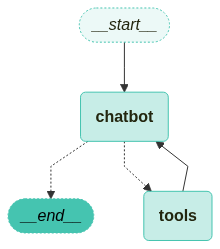

In [10]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

이제 봇에게 훈련 데이터 외의 질문을 할 수 있습니다.

- STEP 1: Chatbot질의 단계
- STEP 2: 도구 선택 단계
- STEP 3: Tool을 활용한 인터넷 검색 단계
- STEP 4: tool과 bind된 LLM이 실행하는 단계
- STEP 5: 결과 출력 단계

In [11]:
inputs = {"messages": "테디노트 YouTube 채널에 대해서 검색해 줘"}

for event in graph.stream(inputs, stream_mode="values"):
    for key, value in event.items():
        print(f"\n==============\nSTEP: {key}\n==============\n")
        # display_message_tree(value["messages"][-1])
        print(value[-1])


STEP: messages

content='테디노트 YouTube 채널에 대해서 검색해 줘' additional_kwargs={} response_metadata={} id='7004cb24-d1e2-4ee5-9972-6988f1da8db0'

STEP: messages

content='' additional_kwargs={'tool_calls': [{'id': 'call_f8DzNMRPg3uya73RhUG2zwbQ', 'function': {'arguments': '{"query":"테디노트 YouTube 채널"}', 'name': 'tavily_web_search'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 105, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CFsTpEvaY1mF5A1BSSR5rHKGU03MN', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='run--3cf898dc-46da-4c20-8505-438f7c1b7328-0' tool_calls=[{'name': 'tavily_web_search', 'args': {'query': '테디노트 YouTube

도구 호출 후 구조에 대한 이미지

![](./image/tool-message-01.png)

- [이전 실행에 대한 LangSmith 추적](https://smith.langchain.com/public/4f82ddfa-a452-40f3-ab09-4eb088b812a4/r)